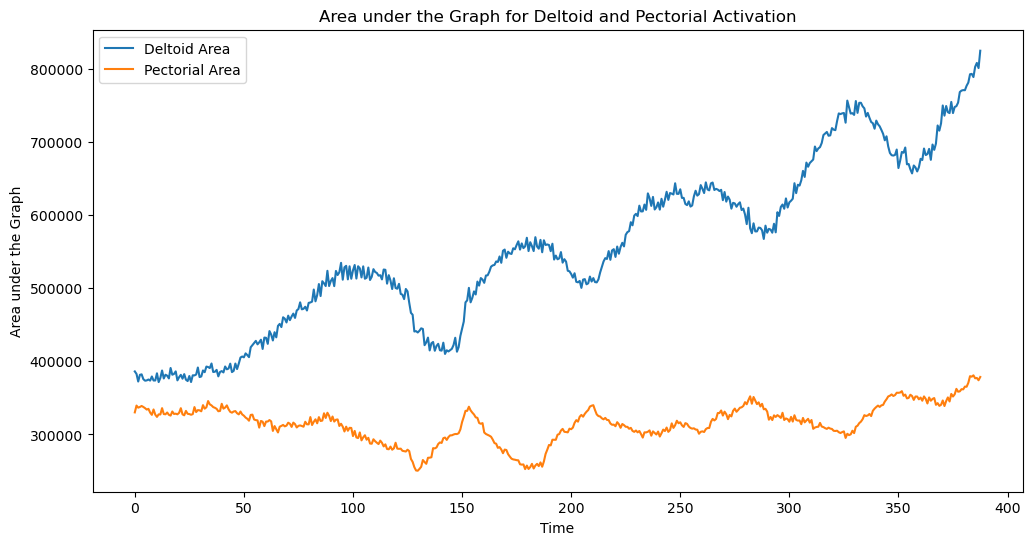

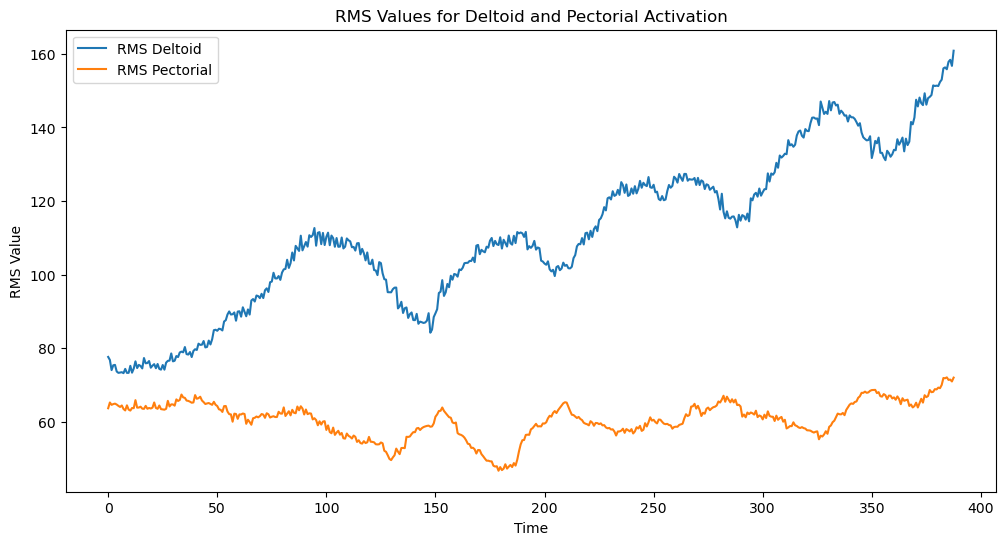

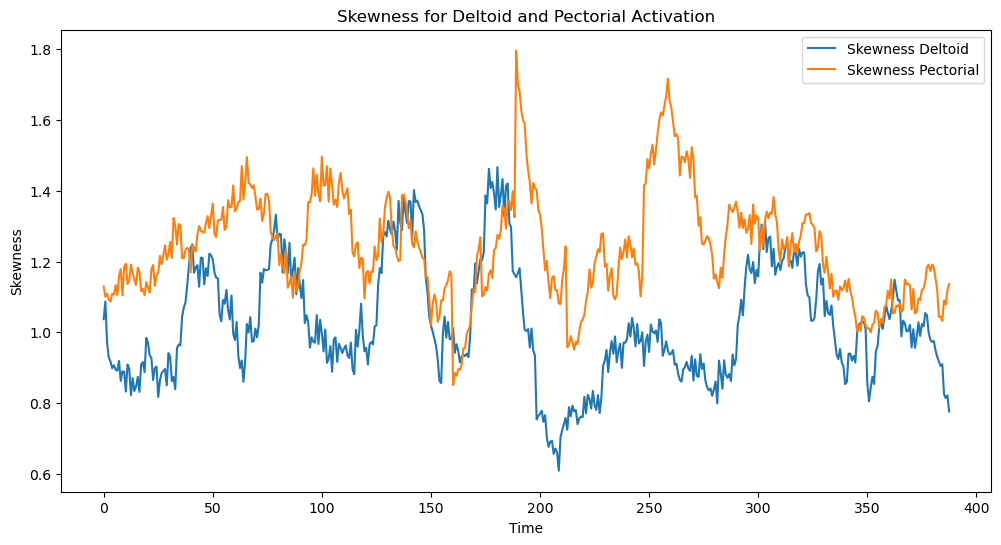

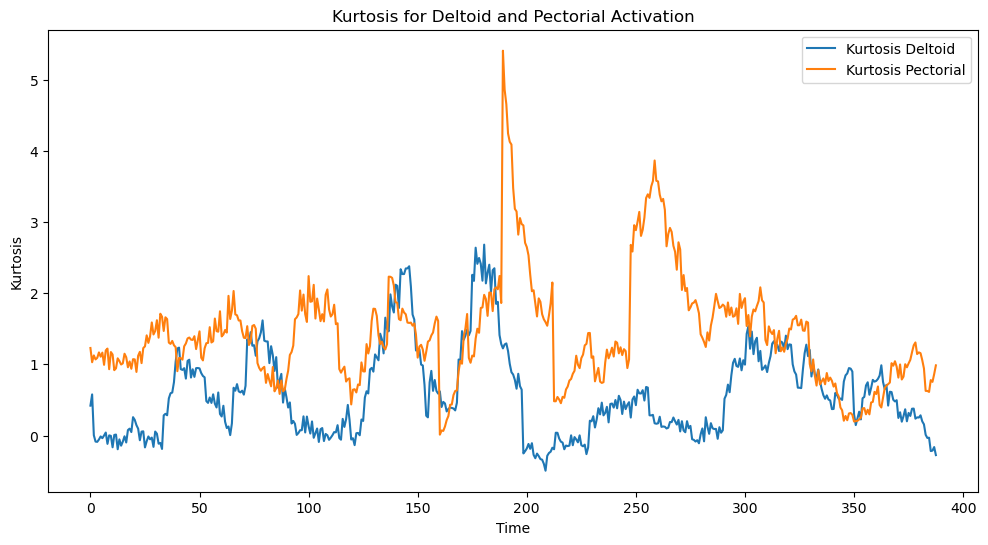

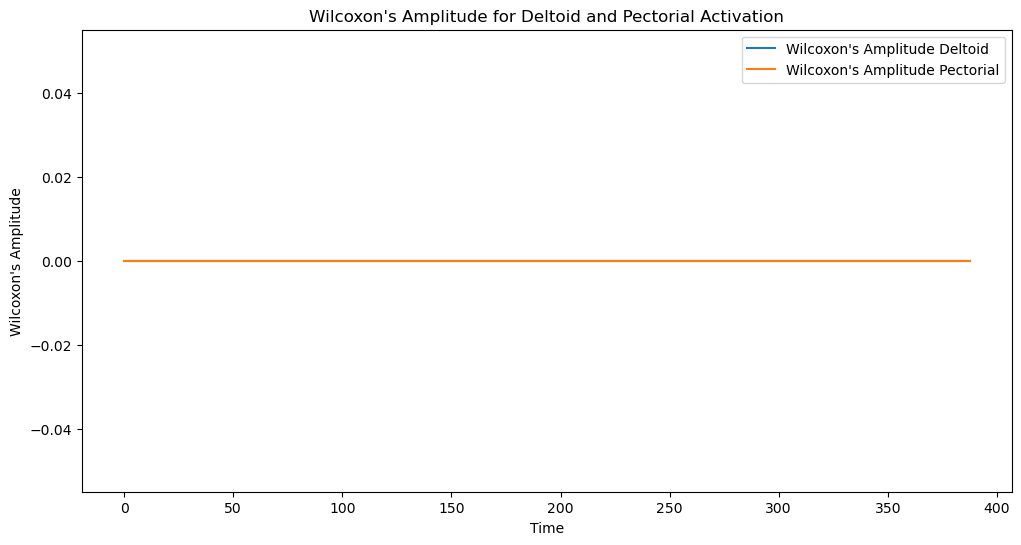

In [1]:
from scipy.stats import skew, kurtosis, wilcoxon
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV data into a Pandas DataFrame
data = pd.read_csv('preprocessed.csv')


# Extract the 'del' and 'pec' columns as NumPy arrays
del_data = data.iloc[:, 1].values
pec_data = data.iloc[:, 2].values
time = data.iloc[:, 0].values

# Define the window size for calculating the area under the graph
window_size = 6000
overlap = 200

# Create lists to store the calculated areas, RMS values, skewness, kurtosis, and Wilcoxon's amplitude
areas = []
rms_del = []
rms_pec = []
skewness_del = []
skewness_pec = []
kurtosis_del = []
kurtosis_pec = []
wilcoxon_amp_del = []
wilcoxon_amp_pec = []

# Calculate the attributes for 'del' and 'pec' using the sliding window
for i in range(0, len(del_data) - window_size + 1, overlap):
    # Area under the graph
    del_area = np.trapz(del_data[i:i + window_size], dx=1)
    pec_area = np.trapz(pec_data[i:i + window_size], dx=1)
    
    # RMS values
    rms_del_value = np.sqrt(np.mean(np.square(del_data[i:i + window_size])))
    rms_pec_value = np.sqrt(np.mean(np.square(pec_data[i:i + window_size])))
    
    # Skewness
    skewness_del_value = skew(del_data[i:i + window_size])
    skewness_pec_value = skew(pec_data[i:i + window_size])
    
    # Kurtosis
    kurtosis_del_value = kurtosis(del_data[i:i + window_size])
    kurtosis_pec_value = kurtosis(pec_data[i:i + window_size])
    
    # Wilcoxon's Amplitude
    wilcoxon_amp_del_value = wilcoxon(del_data[i:i + window_size]).statistic
    wilcoxon_amp_pec_value = wilcoxon(pec_data[i:i + window_size]).statistic
    
    areas.append((time[i], del_area, pec_area))
    rms_del.append((time[i], rms_del_value))
    rms_pec.append((time[i], rms_pec_value))
    skewness_del.append((time[i], skewness_del_value))
    skewness_pec.append((time[i], skewness_pec_value))
    kurtosis_del.append((time[i], kurtosis_del_value))
    kurtosis_pec.append((time[i], kurtosis_pec_value))
    wilcoxon_amp_del.append((time[i], wilcoxon_amp_del_value))
    wilcoxon_amp_pec.append((time[i], wilcoxon_amp_pec_value))

# Convert the lists of attributes to DataFrames
areas_df = pd.DataFrame(areas, columns=['time', 'del_area', 'pec_area'])
rms_del_df = pd.DataFrame(rms_del, columns=['time', 'rms_del'])
rms_pec_df = pd.DataFrame(rms_pec, columns=['time', 'rms_pec'])
skewness_del_df = pd.DataFrame(skewness_del, columns=['time', 'skewness_del'])
skewness_pec_df = pd.DataFrame(skewness_pec, columns=['time', 'skewness_pec'])
kurtosis_del_df = pd.DataFrame(kurtosis_del, columns=['time', 'kurtosis_del'])
kurtosis_pec_df = pd.DataFrame(kurtosis_pec, columns=['time', 'kurtosis_pec'])
wilcoxon_amp_del_df = pd.DataFrame(wilcoxon_amp_del, columns=['time', 'wilcoxon_amp_del'])
wilcoxon_amp_pec_df = pd.DataFrame(wilcoxon_amp_pec, columns=['time', 'wilcoxon_amp_pec'])

# Plot the areas under the graph
plt.figure(figsize=(12, 6))
plt.plot(areas_df['time'], areas_df['del_area'], label='Deltoid Area')
plt.plot(areas_df['time'], areas_df['pec_area'], label='Pectorial Area')
plt.xlabel('Time')
plt.ylabel('Area under the Graph')
plt.legend()
plt.title('Area under the Graph for Deltoid and Pectorial Activation')
plt.show()

# Plot the RMS values
plt.figure(figsize=(12, 6))
plt.plot(rms_del_df['time'], rms_del_df['rms_del'], label='RMS Deltoid')
plt.plot(rms_pec_df['time'], rms_pec_df['rms_pec'], label='RMS Pectorial')
plt.xlabel('Time')
plt.ylabel('RMS Value')
plt.legend()
plt.title('RMS Values for Deltoid and Pectorial Activation')
plt.show()

# Plot the Skewness
plt.figure(figsize=(12, 6))
plt.plot(skewness_del_df['time'], skewness_del_df['skewness_del'], label='Skewness Deltoid')
plt.plot(skewness_pec_df['time'], skewness_pec_df['skewness_pec'], label='Skewness Pectorial')
plt.xlabel('Time')
plt.ylabel('Skewness')
plt.legend()
plt.title('Skewness for Deltoid and Pectorial Activation')
plt.show()

# Plot the Kurtosis
plt.figure(figsize=(12, 6))
plt.plot(kurtosis_del_df['time'], kurtosis_del_df['kurtosis_del'], label='Kurtosis Deltoid')
plt.plot(kurtosis_pec_df['time'], kurtosis_pec_df['kurtosis_pec'], label='Kurtosis Pectorial')
plt.xlabel('Time')
plt.ylabel('Kurtosis')
plt.legend()
plt.title('Kurtosis for Deltoid and Pectorial Activation')
plt.show()

# Plot Wilcoxon's Amplitude
plt.figure(figsize=(12, 6))
plt.plot(wilcoxon_amp_del_df['time'], wilcoxon_amp_del_df['wilcoxon_amp_del'], label="Wilcoxon's Amplitude Deltoid")
plt.plot(wilcoxon_amp_pec_df['time'], wilcoxon_amp_pec_df['wilcoxon_amp_pec'], label="Wilcoxon's Amplitude Pectorial")
plt.xlabel('Time')
plt.ylabel("Wilcoxon's Amplitude")
plt.legend()
plt.title("Wilcoxon's Amplitude for Deltoid and Pectorial Activation")
plt.show()

In [2]:

combined_df = areas_df.merge(rms_del_df, on='time')
combined_df = combined_df.merge(rms_pec_df, on='time')
combined_df = combined_df.merge(skewness_del_df, on='time')
combined_df = combined_df.merge(skewness_pec_df, on='time')
combined_df = combined_df.merge(kurtosis_del_df, on='time')
combined_df = combined_df.merge(kurtosis_pec_df, on='time')



In [3]:
combined_df

,time,del_area,pec_area,rms_del,rms_pec,skewness_del,skewness_pec,kurtosis_del,kurtosis_pec
0,0.00000,386113.4740,330116.7785,77.610563,63.661251,1.037047,1.129360,0.420006,1.230355
1,0.78125,382738.4015,339438.6570,76.790597,65.224325,1.087041,1.100205,0.577893,1.029978
2,1.56250,372300.6105,336567.3635,74.032161,64.587699,0.970239,1.109534,0.004276,1.125994
3,2.34375,381455.3460,337560.0105,75.349785,64.793560,0.928338,1.092781,-0.084727,1.069883
4,3.12500,382130.0790,338882.2095,75.444598,64.915199,0.917872,1.086829,-0.088430,1.091911
...,...,...,...,...,...,...,...,...,...
492,384.37500,788503.8510,380780.0470,155.825333,72.053158,0.910122,1.032019,-0.030115,0.613202
493,385.15625,802472.9605,376743.0025,157.841793,71.371062,0.825717,1.090371,-0.218181,0.779069
494,385.93750,807824.5855,377170.0640,158.395158,71.450037,0.814237,1.078005,-0.211966,0.754305
495,386.71875,800768.9485,374055.6930,156.739703,70.944195,0.821760,1.119494,-0.161754,0.863635


In [4]:
combined_df.to_csv('GYM_ATTRIBUTES_DATASET.csv', index=False)

In [5]:
areas_df['diff'] = areas_df['pec_area']-areas_df['del_area']
areas_df.shape

(497, 4)

In [6]:
from sklearn.preprocessing import MinMaxScaler
areas_df['diff']
scaler = MinMaxScaler()
areas_df['scaled_difference'] = scaler.fit_transform(areas_df[['diff']])

In [7]:
labels = []
for i in areas_df['scaled_difference']:
    if 0 < i < 0.4:
        labels.append("Bad")
    elif 0.3 <= i < 0.5:
        labels.append("Fair")
    else:
        labels.append("Good")
    

In [8]:
areas_df['labels']=labels

In [9]:
areas_df

,time,del_area,pec_area,diff,scaled_difference,labels
0,0.00000,386113.4740,330116.7785,-55996.6955,0.951713,Good
1,0.78125,382738.4015,339438.6570,-43299.7445,0.981969,Good
2,1.56250,372300.6105,336567.3635,-35733.2470,1.000000,Good
3,2.34375,381455.3460,337560.0105,-43895.3355,0.980550,Good
4,3.12500,382130.0790,338882.2095,-43247.8695,0.982093,Good
...,...,...,...,...,...,...
492,384.37500,788503.8510,380780.0470,-407723.8040,0.113567,Bad
493,385.15625,802472.9605,376743.0025,-425729.9580,0.070659,Bad
494,385.93750,807824.5855,377170.0640,-430654.5215,0.058924,Bad
495,386.71875,800768.9485,374055.6930,-426713.2555,0.068316,Bad


In [10]:
label_counts = areas_df['labels'].value_counts()
print(label_counts)

Good    261
Bad     192
Fair     44
Name: labels, dtype: int64


In [11]:
max_del = del_data.max()
min_del = del_data.min()
max_pec = pec_data.max()
min_pec = pec_data.min()

print("Max Deltoid Activation:", max_del)
print("Min Deltoid Activation:", min_del)
print("Max Pectorial Activation:", max_pec)
print("Min Pectorial Activation:", min_pec)

Max Deltoid Activation: 439.848
Min Deltoid Activation: 0.0
Max Pectorial Activation: 248.188
Min Pectorial Activation: 0.0


In [12]:
duration = time[-1] - time[0]  # Total duration of the dataset
peak_time_del = time[np.argmax(del_data)]
peak_time_pec = time[np.argmax(pec_data)]

print("Total Duration:", duration)
print("Time of Peak Deltoid Activation:", peak_time_del)
print("Time of Peak Pectorial Activation:", peak_time_pec)

Total Duration: 411.49609375
Time of Peak Deltoid Activation: 349.3125
Time of Peak Pectorial Activation: 212.33203125


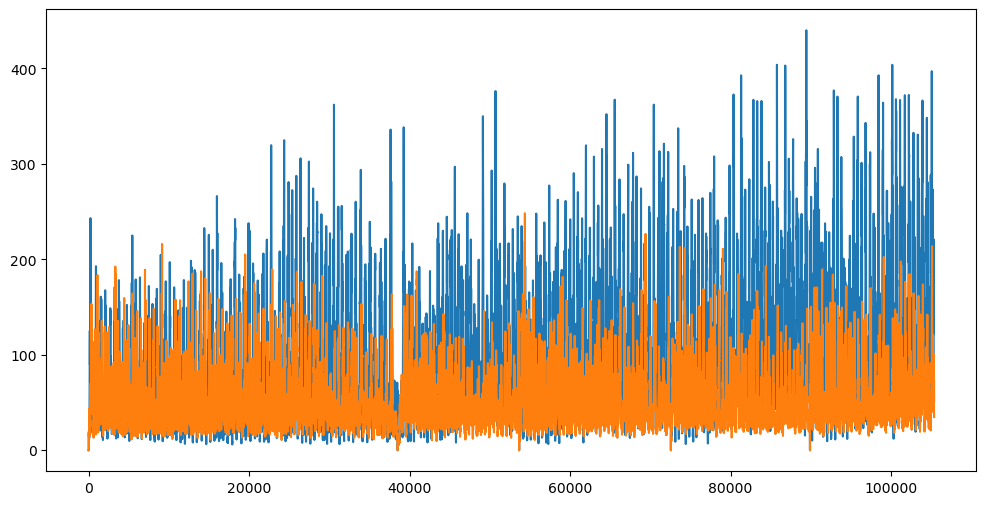

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(del_data)
plt.plot(pec_data)

In [14]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [15]:
X = areas_df.iloc[:,:-1]

In [16]:
y = areas_df.iloc[:,-1]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.2, random_state=42)

In [18]:
from tensorflow import keras
from tensorflow.keras import layers

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input,BatchNormalization,Activation,Dropout

In [20]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, BatchNormalization
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming y_train and y_test contain categorical labels (strings)
# Encode categorical labels into integers
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert integers to one-hot encoded vectors
y_train_one_hot = tf.keras.utils.to_categorical(y_train_encoded)
y_test_one_hot = tf.keras.utils.to_categorical(y_test_encoded)

# Reshape X_train and X_test to add the timestep dimension
X_train_reshaped = np.expand_dims(X_train, axis=1)
X_test_reshaped = np.expand_dims(X_test, axis=1)

# Initialize the Sequential model
model = Sequential()

# Add an LSTM layer with batch normalization
model.add(LSTM(64, input_shape=(1, X_train.shape[1]), return_sequences=True))
model.add(BatchNormalization())

# Add a second LSTM layer with batch normalization
model.add(LSTM(32, return_sequences=True))
model.add(BatchNormalization())

# Add a third LSTM layer with batch normalization
model.add(LSTM(16))
model.add(BatchNormalization())

# Add a Dense output layer with 3 units and softmax activation for multiclass classification
model.add(Dense(3, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
model.fit(X_train_reshaped, y_train_one_hot, epochs=20, batch_size=32, validation_split=0.2)

# Make predictions on the test set
y_pred = model.predict(X_test_reshaped)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_test_encoded, y_pred_classes)
precision = precision_score(y_test_encoded, y_pred_classes, average='weighted')
recall = recall_score(y_test_encoded, y_pred_classes, average='weighted')
f1 = f1_score(y_test_encoded, y_pred_classes, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)



2024-08-27 23:08:02.474667: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 1, 64)             17920     
                                                                 
 batch_normalization (BatchN  (None, 1, 64)            256       
 ormalization)                                                   
                                                                 
 lstm_1 (LSTM)               (None, 1, 32)             12416     
                                                                 
 batch_normalization_1 (Batc  (None, 1, 32)            128       
 hNormalization)                                                 
                                                                 
 lstm_2 (LSTM)               (None, 16)                3136      
                                                                 
 batch_normalization_2 (Batc  (None, 16)               6

/Users/pranavtpattanashetty/opt/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 1, 64)             17920     
                                                                 
 batch_normalization (BatchN  (None, 1, 64)            256       
 ormalization)                                                   
                                                                 
 lstm_1 (LSTM)               (None, 1, 32)             12416     
                                                                 
 batch_normalization_1 (Batc  (None, 1, 32)            128       
 hNormalization)                                                 
                                                                 
 lstm_2 (LSTM)               (None, 16)                3136      
                                                                 
 batch_normalization_2 (Batc  (None, 16)               6

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Assuming X_train, X_test, y_train, and y_test are your input and target data

# Encode categorical labels into integers
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert integers to one-hot encoded vectors
y_train_one_hot = tf.keras.utils.to_categorical(y_train_encoded)
y_test_one_hot = tf.keras.utils.to_categorical(y_test_encoded)

# Initialize the Sequential model
model = Sequential()

# Add a Dense input layer
model.add(Dense(128, activation='sigmoid', input_shape=(X_train.shape[1],)))

# Add batch normalization layer
model.add(BatchNormalization())

# Add dropout layer
model.add(Dropout(0.2))

# Add a second Dense hidden layer
model.add(Dense(64, activation='relu'))

# Add batch normalization layer
model.add(BatchNormalization())

# Add dropout layer
model.add(Dropout(0.2))

# Add a third Dense hidden layer
model.add(Dense(32, activation='relu'))

# Add batch normalization layer
model.add(BatchNormalization())

# Add dropout layer
model.add(Dropout(0.2))

# Add a Dense output layer with 3 units and softmax activation for multiclass classification
model.add(Dense(3, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
model.fit(X_train, y_train_one_hot, epochs=30, batch_size=32, validation_split=0.2)

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_test_encoded, y_pred_classes)
precision = precision_score(y_test_encoded, y_pred_classes, average='weighted')
recall = recall_score(y_test_encoded, y_pred_classes, average='weighted')
f1 = f1_score(y_test_encoded, y_pred_classes, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 128)               768       
                                                                 
 batch_normalization_3 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_4 (Batc  (None, 64)               256       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 64)               

In [23]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [24]:
all_predictions_prob = model.predict(X)
all_predictions = np.argmax(all_predictions_prob, axis=1)

# Convert predictions back to original labels
predicted_labels_all = label_encoder.inverse_transform(all_predictions)

# Reshape the predictions into sets of 30 reps
predicted_labels_sets = [predicted_labels_all[i:i+30] for i in range(0, len(predicted_labels_all), 30)]

# Print the predicted labels for the first set
print("Predicted Labels for the First Set:")
print(predicted_labels_sets)


16/16 [==============================] - 0s 790us/step
Predicted Labels for the First Set:
[array(['Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good'], dtype=object), array(['Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good'], dtype=object), array(['Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good', 'Good',
       'Good', 'Good', 'Good', 'Good', 'Good', 'Good'], dtype=object), array(['Good', 'Good', 'Good', 'Good', 'Good', 'Good', '

In [29]:
import numpy as np
fitness_level = 0.8
experience_level = 1.5

def evaluate_set_feedback(predicted_labels_set, fitness_level, experience_level, threshold_percentage=50):
    # Calculate the percentage of 'Bad' reps in the set
    bad_rep_percentage = (np.sum(np.array(predicted_labels_set) == 'Bad') / len(predicted_labels_set)) * 100

    # Provide feedback on the set
    if bad_rep_percentage <= threshold_percentage:
        feedback = 'Good Set'
    else:
        feedback = 'Bad Set'
    adjustment_factor = 0.8 * fitness_level * experience_level

    # Adjust the number of reps based on the percentage of bad reps and additional factors
    if bad_rep_percentage > threshold_percentage:
        # Decrease the number of reps by a certain factor based on fitness and experience
        adjustment_factor = 0.8 * fitness_level * experience_level
        
        # Adjust based on the performance threshold
        if bad_rep_percentage > 60:  # If bad reps exceed 60%
            adjustment_factor *= 0.7  # Decrease by 30%
        elif bad_rep_percentage > 30:  # If bad reps exceed 40%
            adjustment_factor *= 0.85  # Decrease by 15%
        
        adjusted_reps = max(int(len(predicted_labels_set) * adjustment_factor), 1)  # Ensure at least 1 rep
    else:
        adjusted_reps = len(predicted_labels_set)

    return feedback, adjusted_reps

# Example usage:



# Evaluate each set and provide feedback
for i, predicted_labels_set in enumerate(predicted_labels_sets, 1):
    set_feedback, adjusted_reps = evaluate_set_feedback(predicted_labels_set, fitness_level, experience_level)
    print(f"Set {i}: {set_feedback}, Adjusted Reps: {adjusted_reps}")


Set 1: Good Set, Adjusted Reps: 30
Set 2: Good Set, Adjusted Reps: 30
Set 3: Good Set, Adjusted Reps: 30
Set 4: Good Set, Adjusted Reps: 30
Set 5: Good Set, Adjusted Reps: 30
Set 6: Good Set, Adjusted Reps: 30
Set 7: Good Set, Adjusted Reps: 30
Set 8: Bad Set, Adjusted Reps: 20
Set 9: Good Set, Adjusted Reps: 30
Set 10: Good Set, Adjusted Reps: 30
Set 11: Bad Set, Adjusted Reps: 20
Set 12: Bad Set, Adjusted Reps: 20
Set 13: Good Set, Adjusted Reps: 30
Set 14: Bad Set, Adjusted Reps: 20
Set 15: Bad Set, Adjusted Reps: 20
Set 16: Bad Set, Adjusted Reps: 20
Set 17: Bad Set, Adjusted Reps: 11


In [80]:
# Importing necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
import numpy as np


# Splitting the dataset into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating a pipeline with batch normalization
def batch_norm(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    X_normalized = (X - mean) / std
    return X_normalized

pipeline = make_pipeline(
    FunctionTransformer(batch_norm),
    RandomForestClassifier(n_estimators=100, random_state=42)
)

# Training the model
pipeline.fit(X_train, y_train)

# Making predictions on the test set
y_pred = pipeline.predict(X_test)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.99


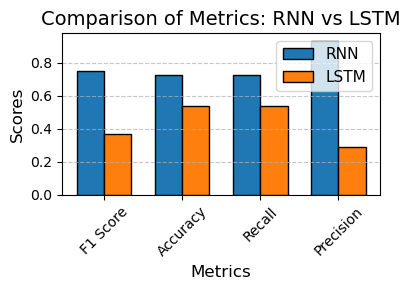

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have calculated metrics for both RNN and ANN models and stored them in separate variables
# Let's create some sample data for demonstration
# Replace these with actual metric values for your models
rnn_metrics = {'F1 Score': 0.751, 'Accuracy': 0.73, 'Recall': 0.73, 'Precision': 0.933}
ann_metrics = {'F1 Score': 0.37, 'Accuracy': 0.54, 'Recall': 0.54, 'Precision': 0.29}


# Get the metric names and values for RNN and ANN
metrics = list(rnn_metrics.keys())
rnn_values = list(rnn_metrics.values())
ann_values = list(ann_metrics.values())

# Set the width of the bars
bar_width = 0.35

# Set the positions of the bars on the x-axis
rnn_positions = np.arange(len(metrics))
ann_positions = [x + bar_width for x in rnn_positions]

plt.figure(figsize=(4, 3))

# Plotting the bars with custom colors and edge color
plt.bar(rnn_positions, rnn_values, color='#1f77b4', width=bar_width, label='RNN', edgecolor='black')
plt.bar(ann_positions, ann_values, color='#ff7f0e', width=bar_width, label='LSTM', edgecolor='black')

# Adding labels and title
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Scores', fontsize=12)
plt.title('Comparison of Metrics: RNN vs LSTM', fontsize=14)

# Rotating x-axis labels for better readability
plt.xticks([r + bar_width/2 for r in range(len(metrics))], metrics, rotation=45)

# Adding gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding legend
plt.legend(fontsize=11)

# Adjusting layout to prevent clipping of labels
plt.tight_layout()

# Show plot
plt.show()


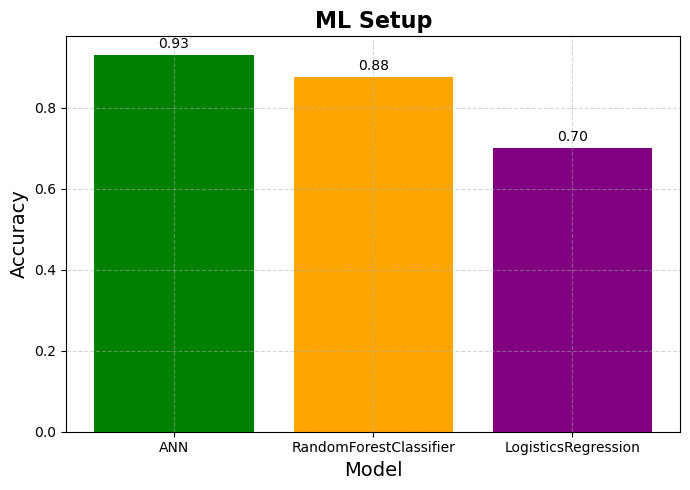

In [27]:
import matplotlib.pyplot as plt

# Define the data
accuracies = [0.93, 0.875, 0.7]
labels = ['ANN', 'RandomForestClassifier', 'LogisticsRegression']
colors = ['green', 'orange', 'purple']

# Create a figure and axis
fig, ax = plt.subplots(figsize=(7, 5))  # Set a larger figure size

# Plot the data as bars
bars = ax.bar(labels, accuracies, color=colors)

# Add labels to the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate('%.2f' % height,
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Set axis labels and title
ax.set_xlabel('Model', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_title('ML Setup', fontsize=16, fontweight='bold')

# Add grid
ax.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()


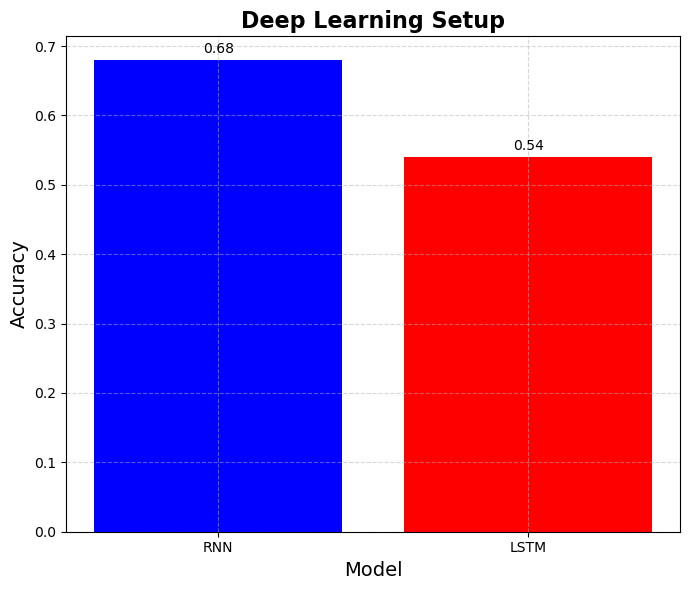

In [33]:
import matplotlib.pyplot as plt

# Define the data
accuracies = [0.68, 0.54]
labels = ['RNN', 'LSTM']
colors = ['blue', 'red']

# Create a figure and axis
fig, ax = plt.subplots(figsize=(7, 6))  # Set a larger figure size

# Plot the data as bars
bars = ax.bar(labels, accuracies, color=colors)

# Add labels to the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate('%.2f' % height,
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Set axis labels and title
ax.set_xlabel('Model', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_title('Deep Learning Setup', fontsize=16, fontweight='bold')

# Add grid
ax.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()


In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, SimpleRNN, BatchNormalization, Activation, Dropout
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import numpy as np

# Assuming X_train and y_train are your training data

# Reshape X_train to add a dummy timestep dimension
X_train = np.random.rand(100, 10, 5)  # Example input data with shape (num_samples, num_timesteps, num_features)

# Create the Sequential model
model = Sequential()

# Input layer
input_shape = X_train.shape[1:]  # Get the input shape from X_train
model.add(Input(shape=input_shape))

# SimpleRNN layers
model.add(SimpleRNN(128, return_sequences=True))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(SimpleRNN(64, return_sequences=True))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(SimpleRNN(32))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(3, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

# Assuming y_train are your target labels
y_train = np.random.randint(3, size=(100,))  # Example labels

# Step 1: Encode target labels using LabelEncoder
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y_train)

# Step 2: Convert integer-encoded labels into one-hot encoded vectors
integer_encoded = integer_encoded.reshape(-1, 1)  # Reshape to a 2D array as required by OneHotEncoder
onehot_encoder = OneHotEncoder(sparse=False)  # Use sparse=False to get a dense array
onehot_encoded = onehot_encoder.fit_transform(integer_encoded)

# Train the model
history = model.fit(X_train, onehot_encoded, epochs=10, batch_size=32, validation_split=0.2)



2024-07-21 11:35:12.250760: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 10, 128)           17152     
                                                                 
 batch_normalization (BatchN  (None, 10, 128)          512       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 10, 128)           0         
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 10, 64)            12352     
                                                                 
 batch_normalization_1 (Batc  (None, 10, 64)           256       
 hNormalization)                                                 
                                                                 
 activation_1 (Activation)   (None, 10, 64)            0

/Users/pranavtpattanashetty/opt/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


3/3 [==============================] - 2s 163ms/step - loss: 1.3249 - accuracy: 0.3375 - val_loss: 1.1130 - val_accuracy: 0.3500
Epoch 2/10
3/3 [==============================] - 0s 17ms/step - loss: 1.1605 - accuracy: 0.4375 - val_loss: 1.1150 - val_accuracy: 0.3500
Epoch 3/10
3/3 [==============================] - 0s 17ms/step - loss: 0.9711 - accuracy: 0.5250 - val_loss: 1.1241 - val_accuracy: 0.2500
Epoch 4/10
3/3 [==============================] - 0s 15ms/step - loss: 0.8399 - accuracy: 0.6125 - val_loss: 1.1229 - val_accuracy: 0.3500
Epoch 5/10
3/3 [==============================] - 0s 15ms/step - loss: 0.8763 - accuracy: 0.6000 - val_loss: 1.1233 - val_accuracy: 0.3500
Epoch 6/10
3/3 [==============================] - 0s 15ms/step - loss: 0.8280 - accuracy: 0.6000 - val_loss: 1.1100 - val_accuracy: 0.3500
Epoch 7/10
3/3 [==============================] - 0s 15ms/step - loss: 0.7422 - accuracy: 0.6250 - val_loss: 1.0981 - val_accuracy: 0.4500
Epoch 8/10
3/3 [=====================

In [ ]:
loss, accuracy = model.evaluate(X_test, onehot_encoder.transform(label_encoder.transform(y_test).reshape(-1, 1)))

print(f"Accuracy: {accuracy * 100:.2f}%")

In [ ]:
# Plot training history
